In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score
from scipy.optimize import linear_sum_assignment

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False)

classes = train_dataset.classes

print(classes)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:16<00:00, 10.3MB/s]
C:\Users\dbere\tf-env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


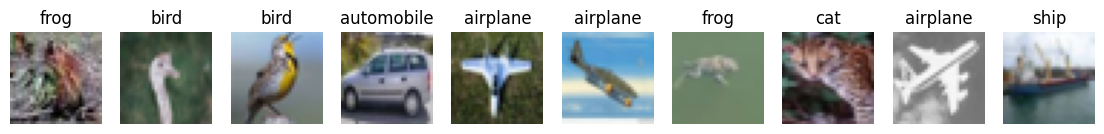

In [10]:
images, labels = next(iter(train_loader))

show_count = 10

fig, axes = plt.subplots(1, show_count, figsize=(14, 2))

for i in range(show_count):
    img = images[i] * 0.5 + 0.5
    img = img.permute(1, 2, 0)

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(classes[labels[i].item()])

plt.show()

In [11]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 2, stride=2),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def get_features(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return x

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvAutoEncoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)

Device: cpu


In [13]:
epochs = 20

losses = []

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, images)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.1437
Epoch 2, Loss: 0.0568
Epoch 3, Loss: 0.0457
Epoch 4, Loss: 0.0407
Epoch 5, Loss: 0.0376
Epoch 6, Loss: 0.0352
Epoch 7, Loss: 0.0329
Epoch 8, Loss: 0.0311
Epoch 9, Loss: 0.0299
Epoch 10, Loss: 0.0290
Epoch 11, Loss: 0.0284
Epoch 12, Loss: 0.0276
Epoch 13, Loss: 0.0271
Epoch 14, Loss: 0.0266
Epoch 15, Loss: 0.0261
Epoch 16, Loss: 0.0258
Epoch 17, Loss: 0.0253
Epoch 18, Loss: 0.0248
Epoch 19, Loss: 0.0248
Epoch 20, Loss: 0.0245


In [14]:
model.eval()

all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        features = model.get_features(images)

        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())

all_features = np.concatenate(all_features)
all_labels = np.concatenate(all_labels)

print(all_features.shape)
print(all_labels.shape)

(2000, 2048)
(2000,)


In [15]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=20,
    max_iter=500
)

clusters = kmeans.fit_predict(all_features)

print(clusters[:20])

[9 7 6 7 9 5 2 2 8 4 1 4 0 2 6 6 0 8 7 0]


In [16]:
def cluster_accuracy(true_labels, cluster_labels):
    matrix = np.zeros((10, 10), dtype=np.int64)

    for true, cluster in zip(true_labels, cluster_labels):
        matrix[true, cluster] += 1

    row_ind, col_ind = linear_sum_assignment(matrix.max() - matrix)

    return matrix[row_ind, col_ind].sum() / len(true_labels)

acc = cluster_accuracy(all_labels, clusters)
ari = adjusted_rand_score(all_labels, clusters)
nmi = normalized_mutual_info_score(all_labels, clusters)

print("Clustering Accuracy:", acc)
print("ARI:", ari)
print("NMI:", nmi)

Clustering Accuracy: 0.246
ARI: 0.06271615552880772
NMI: 0.12620960097978814


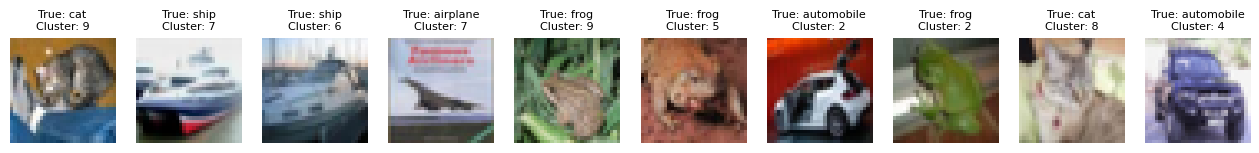

In [17]:
images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    features = model.get_features(images_device)
    predicted_clusters = kmeans.predict(features.cpu().numpy())

show_count = 10

fig, axes = plt.subplots(1, show_count, figsize=(16, 3))

for i in range(show_count):
    img = images[i] * 0.5 + 0.5
    img = img.permute(1, 2, 0)

    true_class = classes[labels[i].item()]
    cluster = predicted_clusters[i]

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"True: {true_class}\nCluster: {cluster}", fontsize=8)

plt.show()

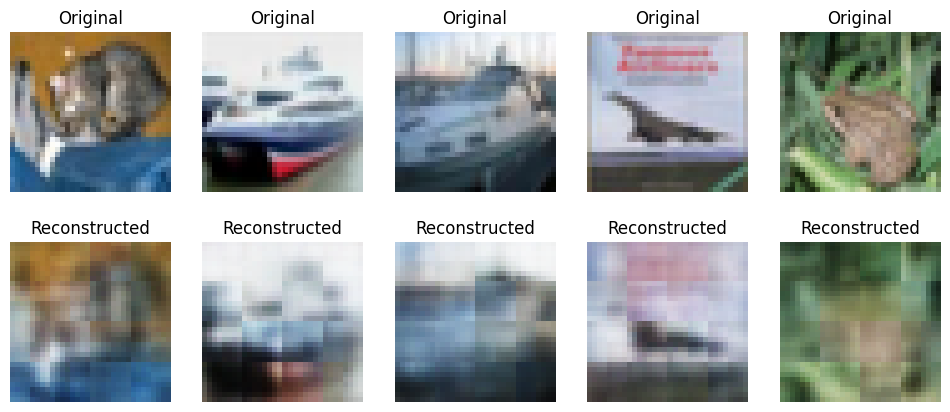

In [18]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

show_count = 5

fig, axes = plt.subplots(2, show_count, figsize=(12, 5))

for i in range(show_count):
    original_img = images[i] * 0.5 + 0.5
    original_img = original_img.permute(1, 2, 0)

    reconstructed_img = reconstructed[i] * 0.5 + 0.5
    reconstructed_img = reconstructed_img.permute(1, 2, 0)

    axes[0][i].imshow(original_img)
    axes[0][i].axis("off")
    axes[0][i].set_title("Original")

    axes[1][i].imshow(reconstructed_img)
    axes[1][i].axis("off")
    axes[1][i].set_title("Reconstructed")

plt.show()